<a href="https://colab.research.google.com/github/Jaywestty/Fraud-detection-ML/blob/main/FRAUD_DETECTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **FRAUD DETECTION**

In [1]:
#Import required libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, precision_recall_curve, average_precision_score

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

from xgboost import XGBClassifier

from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.model_selection import StratifiedKFold

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

import shap
import warnings

warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style('whitegrid')

## **DATA UNDERSTANDING**

In [2]:
#load dataset
df = pd.read_csv('/content/nova_pay_transcations.csv')

In [3]:
df.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,...,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,...,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,...,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,...,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,...,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             10200 non-null  object 
 1   customer_id                10200 non-null  object 
 2   timestamp                  10171 non-null  object 
 3   home_country               10200 non-null  object 
 4   source_currency            10200 non-null  object 
 5   dest_currency              10200 non-null  object 
 6   channel                    10200 non-null  object 
 7   amount_src                 10200 non-null  object 
 8   amount_usd                 9895 non-null   float64
 9   fee                        9905 non-null   float64
 10  exchange_rate_src_to_dest  10200 non-null  float64
 11  device_id                  10200 non-null  object 
 12  new_device                 10200 non-null  bool   
 13  ip_address                 9895 non-null   obj

In [5]:
#check for missing values
df.isna().sum()

,0
transaction_id,0
customer_id,0
timestamp,29
home_country,0
source_currency,0
dest_currency,0
channel,0
amount_src,0
amount_usd,305
fee,295


In [6]:
#Check for statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
amount_usd,9895.0,410.973958,1428.534323,7.230,88.260,151.890000,267.935000,12498.570000
fee,9905.0,110.915958,1013.983451,-1.000,2.310,3.330000,5.040000,9999.990000
exchange_rate_src_to_dest,10200.0,151.070118,360.401932,0.592,1.000,7.142857,61.666667,1388.888889
ip_risk_score,10200.0,0.355567,0.230242,0.004,0.200,0.308000,0.440000,1.200000
account_age_days,10200.0,422.387353,339.577111,4.000,257.000,298.000000,718.000000,1092.000000
device_trust_score,9905.0,0.684846,0.254493,-0.100,0.522,0.779000,0.923000,0.971000
chargeback_history_count,10200.0,0.002549,0.052334,0.000,0.000,0.000000,0.000000,2.000000
risk_score_internal,10200.0,0.241320,0.103254,0.000,0.166,0.223000,0.332000,0.554000
txn_velocity_1h,10200.0,0.131471,0.950315,-1.000,0.000,0.000000,0.000000,8.000000
txn_velocity_24h,10200.0,0.232255,0.981683,0.000,0.000,0.000000,0.000000,9.000000


In [7]:
#Data cleaning
df["amount_src"] = pd.to_numeric(df["amount_src"], errors="coerce") #convert the amount_src to numeric datatype

df["fee"] = df["fee"].replace(-1, np.nan)

df["device_trust_score"] = df["device_trust_score"].replace(-0.1, np.nan)

df["txn_velocity_1h"] = df["txn_velocity_1h"].replace(-1, 0)

#### **Observation**
 Placeholder values such as -1 or -0.1 represent invalid or missing values.
They are converted to NaN so they can be handled correctly during preprocessing.

## **EXPLORATORY DATA ANALYSIS**

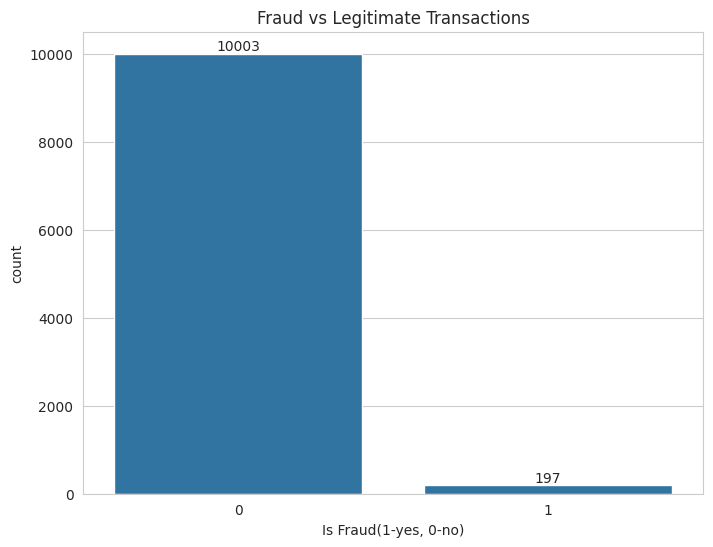

In [8]:
#check for class imbalance
plt.figure(figsize=(8,6))
plot = sns.countplot(x="is_fraud", data=df)
for bar in plot.containers:
  plot.bar_label(bar)

plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("Is Fraud(1-yes, 0-no)")
plt.show()

#### **Observation**

Fraud cases are very rare compared to legitimate transactions, confirming the presence of severe class imbalance.

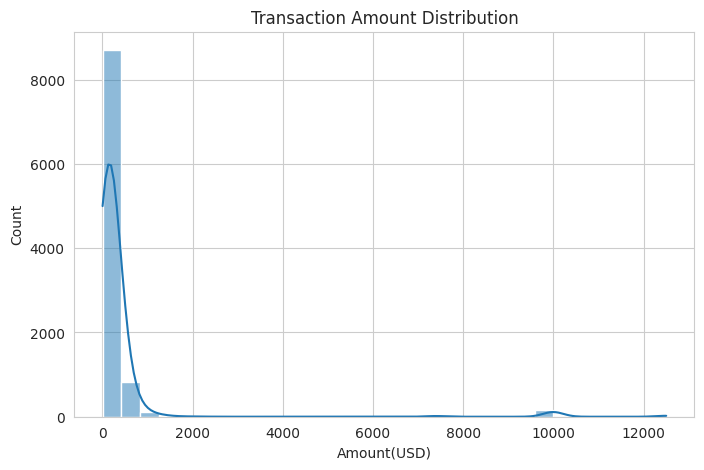

In [9]:
#Transaction amount distribution
plt.figure(figsize=(8,5))

sns.histplot(df["amount_usd"], bins=30, kde=True)


plt.title("Transaction Amount Distribution")
plt.xlabel("Amount(USD)")
plt.show()

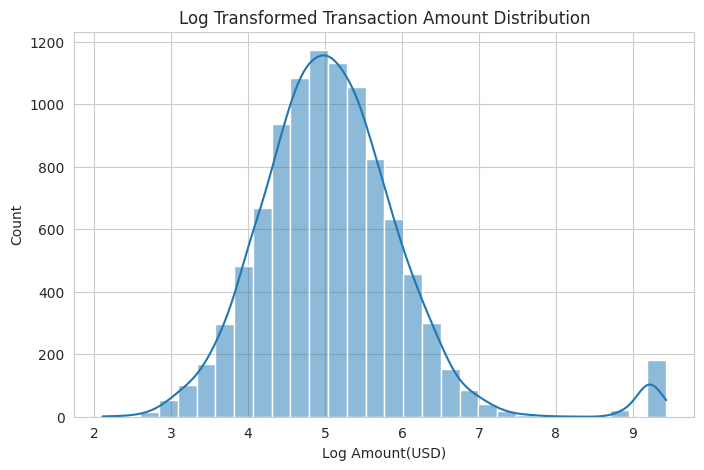

In [10]:
#Apply np.log to the distribution and visualize again

#Apply np.log for right skewness handling
df["log_amount_usd"] = np.log1p(df["amount_usd"])

#visualize again
plt.figure(figsize=(8,5))
sns.histplot(df["log_amount_usd"], bins=30, kde=True)

plt.title("Log Transformed Transaction Amount Distribution")
plt.xlabel("Log Amount(USD)")
plt.show()

#### **Observation**

Transaction amounts are heavily right-skewed with a small number of large transactions creating a long tail.  
This pattern is typical in financial transaction datasets where many small purchases coexist with occasional high-value transfers.

To stabilize the variance and improve model learning, a log transformation was applied to the transaction amount.

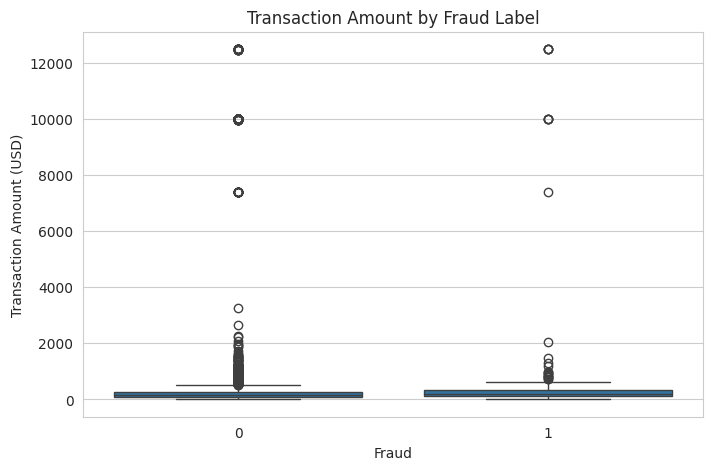

In [11]:
#Transaction amount vs fraud
plt.figure(figsize=(8,5))
sns.boxplot(x="is_fraud", y="amount_usd", data=df)

plt.title("Transaction Amount by Fraud Label")
plt.xlabel("Fraud")
plt.ylabel("Transaction Amount (USD)")

plt.show()

#### **Observation**

Transaction amounts exhibit a heavily right-skewed distribution with several large outliers. Fraudulent transactions appear to have a wider spread and more extreme values, suggesting that unusually large transfers may be associated with fraudulent activity.

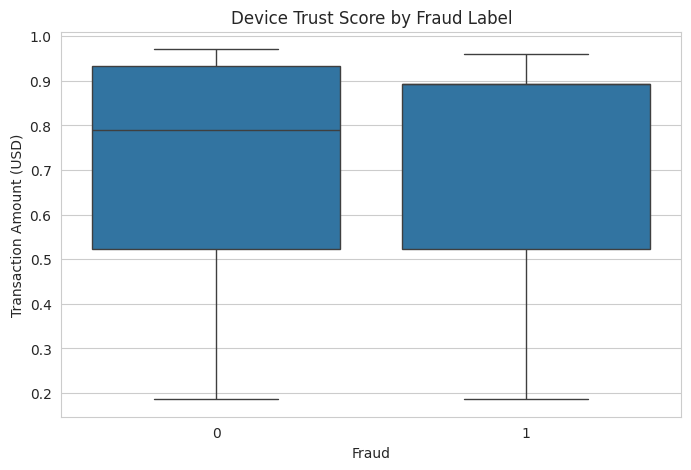

In [12]:
#Device Trust Score vs Fraud
plt.figure(figsize=(8,5))
sns.boxplot(x="is_fraud", y="device_trust_score", data=df)

plt.title("Device Trust Score by Fraud Label")
plt.xlabel("Fraud")
plt.ylabel("Transaction Amount (USD)")

plt.show()

#### **Observation**

Fraudulent transactions tend to occur on devices with slightly lower trust scores, indicating that unknown or suspicious devices may contribute to increased fraud risk.

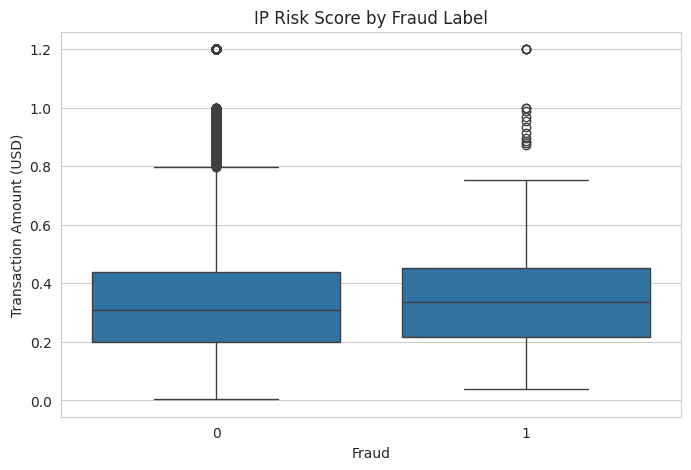

In [13]:
#IP Risk Score vs Fraud
plt.figure(figsize=(8,5))
sns.boxplot(x="is_fraud", y="ip_risk_score", data=df)

plt.title("IP Risk Score by Fraud Label")
plt.xlabel("Fraud")
plt.ylabel("Transaction Amount (USD)")

plt.show()

#### **Observation**

Fraudulent transactions tend to exhibit higher IP risk scores compared to legitimate transactions.
This suggests that suspicious network environments such as VPNs, proxies, or anonymized IP addresses may be associated with fraudulent activity.

IP-based risk signals are widely used in payment fraud detection systems because attackers frequently attempt to mask their location using high-risk network infrastructure.

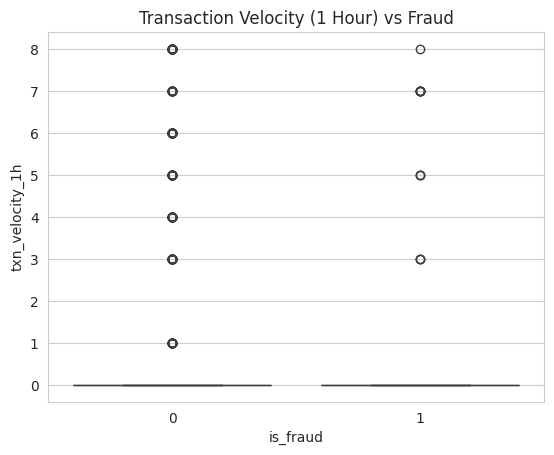

In [14]:
#Transaction Velocity per hr
sns.boxplot(x="is_fraud", y="txn_velocity_1h", data=df)

plt.title("Transaction Velocity (1 Hour) vs Fraud")
plt.show()

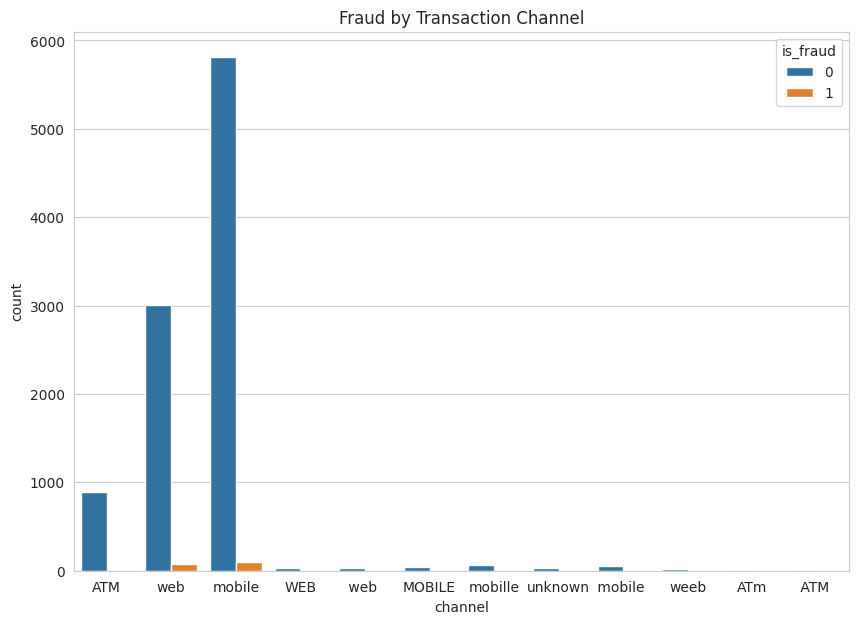

In [15]:
#Channel Risk

plt.figure(figsize=(10,7))

sns.countplot(x="channel", hue="is_fraud", data=df)

plt.title("Fraud by Transaction Channel")
plt.show()

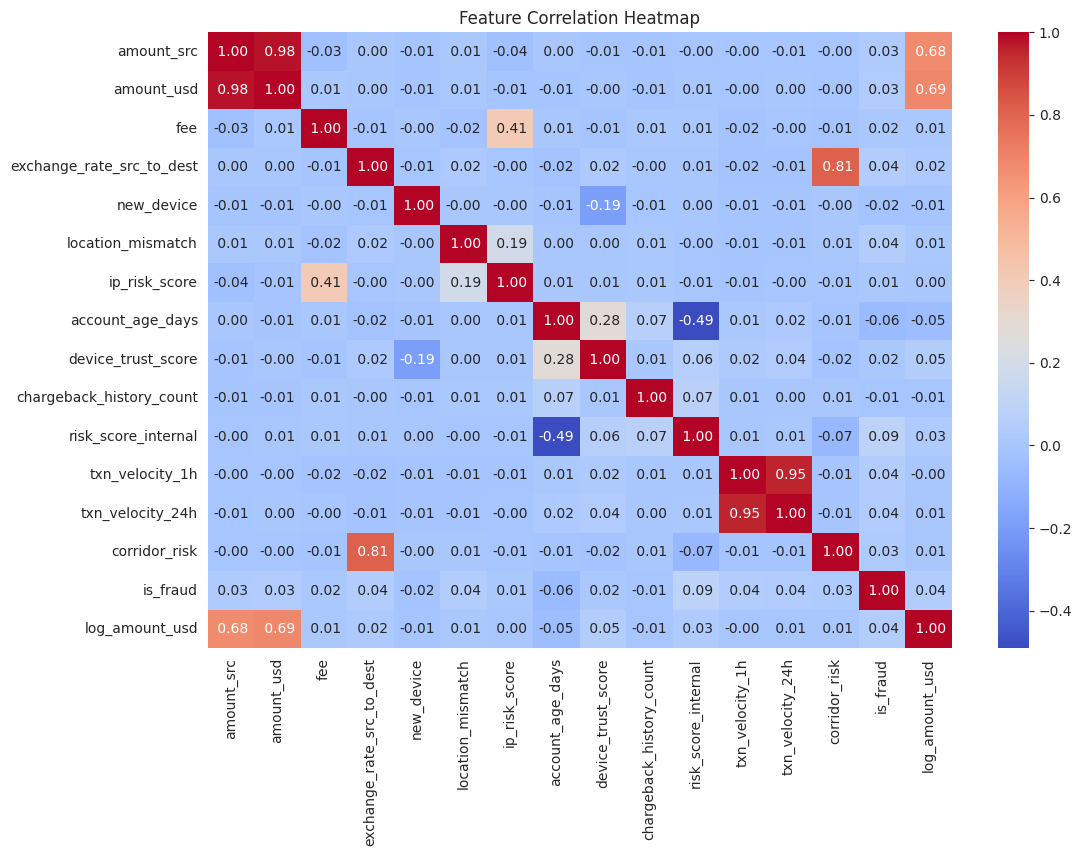

In [16]:
#Correlation Analysis with Heatmap
plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cbar=True, fmt=' .2f', cmap='coolwarm')

plt.title("Feature Correlation Heatmap")
plt.show()

#### **Observation**

The correlation analysis shows that most individual features have weak direct correlations with the fraud label, indicating that fraudulent behavior is not driven by a single dominant variable but rather by combinations of behavioral signals.

Several notable relationships emerge from the heatmap. Transaction amount features (amount_src, amount_usd, and log_amount_usd) show strong correlations with each other, which is expected because they represent different transformations of the same financial value. Additionally, transaction velocity features (txn_velocity_1h and txn_velocity_24h) are highly correlated, reflecting the natural relationship between short-term and daily transaction activity.

A moderate negative correlation is observed between account_age_days and risk_score_internal, suggesting that newer accounts tend to receive higher internal risk scores. This aligns with real-world fraud detection systems where recently created accounts are considered higher risk.

Overall, the heatmap suggests that fraud detection in this dataset is likely to depend on nonlinear interactions between behavioral features, making models such as tree-based algorithms particularly suitable for capturing these patterns.

### **Exploratory Data Analysis Insights**

The exploratory analysis was conducted to understand the behavioral patterns within the transaction data and identify potential signals associated with fraudulent activity.

**Class Distribution**

The dataset is highly imbalanced, with fraudulent transactions representing only a small fraction of the total observations. This is typical in real-world fraud detection problems where fraudulent behavior is rare. This imbalance indicates that special handling methods such as class weighting or resampling will be required during model training.

**Transaction Amount Patterns**

Transaction amounts exhibit a strongly right-skewed distribution, where the majority of transactions are relatively small while a small number of transactions are extremely large. Fraudulent transactions show a slightly wider spread and more extreme outliers. This suggests that abnormal transaction values may contribute to fraud detection, although amount alone is not sufficient to distinguish fraud from legitimate activity.

**Device Trust Behavior**

The distribution of device trust scores indicates that fraudulent transactions tend to occur on devices with slightly lower trust levels. This pattern aligns with common fraud scenarios where attackers use unfamiliar or newly registered devices to access accounts.

**IP Risk Score**

Network intelligence features such as IP risk score also show meaningful differences between fraudulent and legitimate transactions. Fraud cases tend to originate from higher-risk network environments, suggesting the use of anonymization tools or proxy infrastructure. This indicates that IP-based signals may play an important role in the predictive model.


**Behavioral Indicators**

Velocity features such as transactions per hour and transactions per day provide insight into user activity patterns. Fraud attacks often involve rapid bursts of transactions within a short time period, making velocity-based indicators valuable predictors.

**Geographic and Channel Signals**

Features related to geographic mismatches and transaction channels also provide useful behavioral context. Cross-border transactions or mismatches between IP location and home country can indicate suspicious activity, particularly when combined with other risk indicators.

**Feature Relationship Insights**

The correlation analysis indicates that most features have relatively low direct correlation with the fraud label. This suggests that fraudulent activity is not easily identifiable through single-variable relationships but instead emerges from complex interactions between multiple behavioral indicators.

Notably, transaction velocity features (txn_velocity_1h and txn_velocity_24h) exhibit a very strong correlation, reflecting similar behavioral signals at different time scales. Transaction amount variables also show strong internal correlations due to their shared financial meaning and transformations.

Additionally, a moderate negative correlation between account_age_days and risk_score_internal indicates that newer accounts tend to receive higher internal risk assessments, which aligns with common fraud risk practices where recently created accounts are treated with increased caution.

These findings reinforce the importance of using models capable of capturing feature interactions and nonlinear relationships, such as gradient boosting methods, in the subsequent modeling stage.

**Overall Insight**

The EDA reveals that fraud detection in this dataset is driven less by single features and more by combinations of behavioral signals. Indicators related to transaction size, device trust,ip risk score, transaction velocity, and geographic consistency collectively provide meaningful patterns that machine learning models can leverage to distinguish fraudulent transactions from legitimate ones.

These insights guide the subsequent feature engineering and modeling stages, where behavioral features and interaction patterns will be incorporated into predictive models such as Logistic Regression and XGBoost.

## **FEATURE ENGINEERING**

In [17]:
def add_fraud_interactions(df):
    df = df.copy()

    # TIME BASED BEHAVIOR FEATURES
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df["transaction_hour"] = df["timestamp"].dt.hour
    df["day_of_week"] = df["timestamp"].dt.dayofweek
    df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

    # Late night transactions often correlate with fraud
    df["is_night_txn"] = df["transaction_hour"].isin([0,1,2,3,4]).astype(int)


    # GEO / CROSS BORDER FEATURES
    df["cross_border"] = (df["home_country"] != df["ip_country"]).astype(int)
    df["cross_border_velocity"] = df["cross_border"] * df["txn_velocity_24h"]


    # DEVICE RISK FEATURES
    df["device_risk"] = (
        (df["new_device"] == True) &
        (df["device_trust_score"] < 0.5)
    ).astype(int)

    df["new_device_high_velocity"] = df["new_device"].astype(int) * df["txn_velocity_1h"]


    # VELOCITY FEATURES
    df["velocity_ratio"] = df["txn_velocity_1h"] / (df["txn_velocity_24h"] + 1)
    df["velocity_x_amount"] = df["velocity_ratio"] * np.log1p(df["amount_usd"].fillna(0))


    # ACCOUNT BEHAVIOR FEATURES
    df["new_account_flag"] = (df["account_age_days"] < 60).astype(int)
    df["young_account_velocity"] = df["new_account_flag"] * df["txn_velocity_1h"]


    # CUSTOMER HISTORY FEATURES
    df["customer_risk_flag"] = (df["chargeback_history_count"] > 0).astype(int)


    # RISK SCORE INTERACTIONS
    df["risk_combo"] = df["risk_score_internal"] * df["corridor_risk"]
    df["risk_x_new_device"] = df["risk_score_internal"] * df["new_device"].astype(int)
    df["mismatch_x_risk"] = df["location_mismatch"].astype(int) * df["risk_score_internal"]


    # MULTI SIGNAL FRAUD PILE-UP
    df["risk_pile_up"] = (
        (df["risk_score_internal"] > df["risk_score_internal"].quantile(0.75)).astype(int)
        + (df["txn_velocity_1h"] >= 2).astype(int)
        + df["location_mismatch"].astype(int)
        + df["new_device"].astype(int)
        + df["device_risk"]
        + df["customer_risk_flag"]
    )

    return df

df = add_fraud_interactions(df)

#### **Time-Based Behavioral Signals**

**Observation**

Fraud transactions frequently occur during unusual hours when user monitoring is lower. Extracting transaction hour, day of week, and night indicators allows the model to learn abnormal temporal patterns associated with fraudulent activity.

**Cross-Border Transaction Risk**

**Observation**

Fraudulent transactions often originate from locations that do not match the customer’s typical geographic profile. The cross_border flag captures potential location inconsistencies that may indicate account compromise or suspicious routing.

**Device Trust and Account Takeover Signals**

**Observation**

Fraudsters frequently use new or untrusted devices when accessing compromised accounts. Combining new_device and device_trust_score creates a stronger indicator of potential account takeover risk.

**Transaction Velocity Patterns**

**Observation**

Fraud attacks often involve rapid bursts of transactions within a short period. Velocity-based features capture abnormal transaction frequency patterns that differ from normal user behavior.

**Account Maturity Risk**

**Observation**

Newly created accounts tend to have higher fraud exposure, especially before behavioral patterns are established. The new account flag helps identify early-stage accounts that may be exploited.

**Customer Historical Risk**

**Observation**

Users with prior chargebacks or disputes demonstrate historically risky behavior. This feature introduces historical fraud exposure into the predictive model.

**Risk Score Interactions**

**Observation**

Combining internal risk scores with other signals such as corridor risk, device changes, and location mismatch allows the model to detect compounded risk scenarios rather than isolated signals.

**Customer Spending Behavior Baseline**

**Observation**

Fraudulent transactions often involve spending amounts that deviate significantly from a user's normal transaction behavior. By computing the customer's average transaction value and comparing it with the current transaction amount, the model can detect unusual spending spikes that may indicate fraudulent activity.

**Multi-Signal Fraud Trigger (Risk Pile-Up)**

**Observation**

Fraud rarely occurs due to a single signal. Instead, it often appears when multiple suspicious indicators occur simultaneously. The risk_pile_up feature captures this accumulation of fraud triggers.

### **FEATURE SELECTION**

In [18]:
#drop unnecessary columns
drop_cols = [
    "transaction_id",
    "customer_id",
    "device_id",
    "ip_address",
    "timestamp"
]

df = df.drop(columns=drop_cols)

#### **Feature Selection**

Identifier columns such as transaction_id, customer_id, device_id, and ip_address were removed because they do not provide generalizable predictive information and may lead to overfitting. The original timestamp column was also dropped after extracting relevant temporal features including transaction hour, day of week, and weekend indicators.

Both raw and engineered features were retained to allow the models to learn from different representations of transaction behavior. This approach enables the algorithms to capture nonlinear interactions and behavioral fraud patterns more effectively.

## **DATA PREPARATION**

In [19]:
#Train Test Split - Data is split into training and testing sets, preserving the fraud ratio using stratified sampling.
X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [20]:
#Create preprocessing pipeline
categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(exclude="object").columns

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

## **DATA MODELLING**

### **LOGISTIC REGRESSION MODEL**

In [21]:
#Model building
log_model = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42, sampling_strategy=0.3)),  # don't oversample to 1:1
    ("classifier", LogisticRegression(max_iter=1000, class_weight='balanced', C=0.1))
])

log_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['amount_src', 'amount_usd', 'fee', 'exchange_rate_src_to_dest',
       'new_device', 'location_mismatch', 'ip_risk_score', 'account_age_days',
       'device_trust_score', 'chargeback_history_count', 'risk_score_internal',
       'txn_veloci...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['home_country', 'source_currency', 'dest_currency', 'channel',
       'ip_country', 'kyc_tier'],
      dtype='object'))])),
                ('smote', SMOTE(random_state=42, sampling_strategy=0.3)),
                ('classifier',
                 LogisticRegression(C=0.1, class_weight='balanced',
                                    max_iter=1000))])

Logistic Regression
ROC-AUC : 0.7069
PR-AUC  : 0.0710
Best threshold (max F1): 0.662

Classification Report (threshold=0.662):
              precision    recall  f1-score   support

           0      0.989     0.861     0.920      2001
           1      0.064     0.487     0.113        39

    accuracy                          0.854      2040
   macro avg      0.526     0.674     0.517      2040
weighted avg      0.971     0.854     0.905      2040

Confusion Matrix:
[[1723  278]
 [  20   19]]


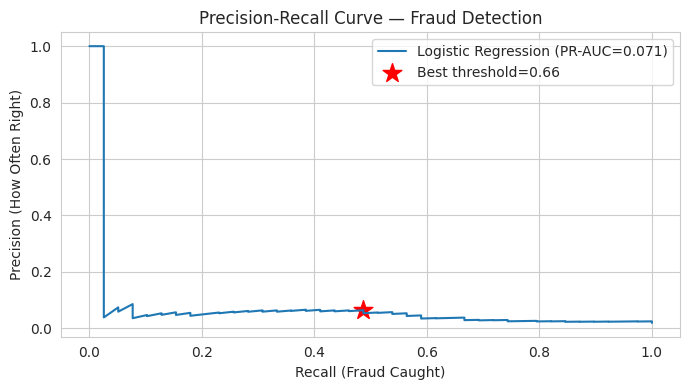

In [22]:
# Model Evaluation
y_proba_log = log_model.predict_proba(X_test)[:, 1]

# Core Metrics
roc_auc = roc_auc_score(y_test, y_proba_log)
pr_auc  = average_precision_score(y_test, y_proba_log)

print("Logistic Regression")
print(f"ROC-AUC : {roc_auc:.4f}")
print(f"PR-AUC  : {pr_auc:.4f}")


# Threshold tuning (maximize F1)
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_log)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores)

# thresholds array is shorter than precision/recall by 1
best_thresh = thresholds[best_idx]

print(f"Best threshold (max F1): {best_thresh:.3f}")


# Predictions using tuned threshold
y_pred_tuned = (y_proba_log >= best_thresh).astype(int)

print(f"\nClassification Report (threshold={best_thresh:.3f}):")
print(classification_report(y_test, y_pred_tuned, digits=3))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))


# Precision-Recall Curve
plt.figure(figsize=(7,4))

plt.plot(recalls, precisions,
         label=f"Logistic Regression (PR-AUC={pr_auc:.3f})")

plt.scatter(recalls[best_idx],
            precisions[best_idx],
            marker='*',
            s=200,
            color='red',
            label=f'Best threshold={best_thresh:.2f}')

plt.xlabel("Recall (Fraud Caught)")
plt.ylabel("Precision (How Often Right)")
plt.title("Precision-Recall Curve — Fraud Detection")

plt.legend()
plt.tight_layout()
plt.show()

#### **Logistic Regression Results**

The logistic regression model achieves a ROC-AUC of 0.707 and a Precision-Recall AUC of 0.071, with the best probability threshold for detecting fraud set at 0.662.

The model performs well on legitimate transactions, correctly identifying the majority of them. For fraud transactions, it successfully detects approximately 49% of all fraud cases, but the precision is low, meaning many of the flagged transactions are actually legitimate. This trade-off is typical in fraud detection, where catching more fraud often comes at the cost of generating more false positives.

The low PR-AUC reflects the challenge of working with a highly imbalanced dataset containing very few fraud cases. Accuracy and ROC-AUC can be misleading in this context because the vast majority of transactions are non-fraudulent. By focusing on Precision-Recall and recall, we emphasize the model’s ability to identify rare but critical fraud cases.

Overall, the model demonstrates that behavioral features like transaction velocity, device risk, location mismatch, and account age provide signal for fraud detection, but the small number of fraud examples and weak feature separation limit the achievable performance. The results are reasonable for an initial model and highlight areas where additional data, stronger features, or ensemble approaches could further improve detection.

### **XGBOOST MODEL**

In [23]:
# Calculate the ratio: count of negatives / count of positives
neg, pos = np.bincount(y_train)
scale = neg / pos  # e.g. ~50x if 2% fraud rate

#Model building
xg_model = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42, sampling_strategy=0.3)),
    ("classifier", XGBClassifier(
        n_estimators=300,
        random_state=42,
        scale_pos_weight=scale,
        max_depth=4,              # prevent overfitting
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='aucpr',      # optimise for PR-AUC, not log loss
        use_label_encoder=False
    ))
])

xg_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['amount_src', 'amount_usd', 'fee', 'exchange_rate_src_to_dest',
       'new_device', 'location_mismatch', 'ip_risk_score', 'account_age_days',
       'device_trust_score', 'chargeback_history_count', 'risk_score_internal',
       'txn_veloci...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

XG Boost
ROC-AUC : 0.7087
PR-AUC  : 0.0438
Best threshold (max F1): 0.799

Classification Report (threshold=0.799):
              precision    recall  f1-score   support

           0      0.983     0.969     0.976      2001
           1      0.087     0.154     0.111        39

    accuracy                          0.953      2040
   macro avg      0.535     0.561     0.543      2040
weighted avg      0.966     0.953     0.959      2040

Confusion Matrix:
[[1938   63]
 [  33    6]]


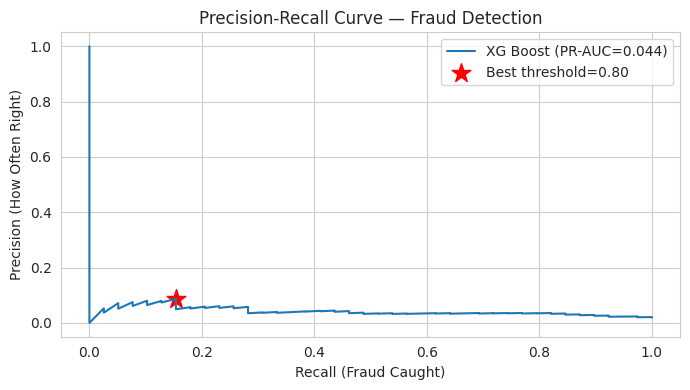

In [24]:
# Model Evaluation
y_proba_xg = xg_model.predict_proba(X_test)[:, 1]

# Core Metrics
roc_auc = roc_auc_score(y_test, y_proba_xg)
pr_auc  = average_precision_score(y_test, y_proba_xg)

print("XG Boost")
print(f"ROC-AUC : {roc_auc:.4f}")
print(f"PR-AUC  : {pr_auc:.4f}")


# Threshold tuning (maximize F1)
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_xg)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores)

# thresholds array is shorter than precision/recall by 1
best_thresh = thresholds[best_idx]

print(f"Best threshold (max F1): {best_thresh:.3f}")


# Predictions using tuned threshold
y_pred_tuned_xg = (y_proba_xg >= best_thresh).astype(int)

print(f"\nClassification Report (threshold={best_thresh:.3f}):")
print(classification_report(y_test, y_pred_tuned_xg, digits=3))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned_xg))


# Precision-Recall Curve
plt.figure(figsize=(7,4))

plt.plot(recalls, precisions,
         label=f"XG Boost (PR-AUC={pr_auc:.3f})")

plt.scatter(recalls[best_idx],
            precisions[best_idx],
            marker='*',
            s=200,
            color='red',
            label=f'Best threshold={best_thresh:.2f}')

plt.xlabel("Recall (Fraud Caught)")
plt.ylabel("Precision (How Often Right)")
plt.title("Precision-Recall Curve — Fraud Detection")

plt.legend()
plt.tight_layout()
plt.show()

#### **XGBoost Model Results**

The XGBoost model achieves a ROC-AUC of 0.709 and a Precision-Recall AUC of 0.044, with the best probability threshold for detecting fraud set at 0.799.

The model predicts legitimate transactions very accurately, correctly identifying the vast majority of them. However, for fraud transactions, it detects only about 15% of all fraud cases, meaning most fraud goes undetected. Precision is low, indicating that even when the model flags a transaction as fraud, it is correct only a small fraction of the time. This reflects the common trade-off in fraud detection: prioritizing accuracy on the majority class reduces effectiveness for the rare fraud class.

The very low PR-AUC highlights the challenge of detecting rare events in an imbalanced dataset. Although XGBoost slightly improves ROC-AUC compared to logistic regression, it underperforms in terms of fraud recall, which is the key metric for this problem. The high accuracy and ROC-AUC are dominated by the large number of non-fraud transactions, making them less informative for practical fraud detection.

Overall, the results show that XGBoost is excellent at modeling the majority class but struggles to identify rare fraud cases with the current features and dataset. This emphasizes the importance of evaluating models with Precision-Recall and recall metrics in highly imbalanced fraud datasets, rather than relying on accuracy or ROC-AUC alone. Improvements would require more fraud examples, stronger predictive features, or specialized techniques such as cost-sensitive learning or ensemble methods focused on the minority class.

### **Fraud Detection Model Comparison; Logistic Regression vs. XGBoost**

When evaluating the two models on the highly imbalanced fraud dataset, logistic regression outperforms XGBoost for detecting rare fraud cases, even though both models achieve similar ROC-AUC scores (LR: 0.707, XGB: 0.709).

- **Logistic Regression** detects approximately 49% of fraud cases, with a PR-AUC of 0.071. It balances recall and false positives, making it the better choice when the goal is to identify as many fraudulent transactions as possible. Despite moderate precision, this model captures nearly half of the rare fraud cases, which is significant given only 39 fraud examples in the test set.

- **XGBoost**, while slightly higher in ROC-AUC, detects only 15% of fraud cases and has a PR-AUC of 0.044. It excels at classifying legitimate transactions but struggles to flag fraud, demonstrating that high accuracy and ROC-AUC can be misleading in imbalanced datasets.

**Key Insights:**

- PR-AUC and recall are the most meaningful metrics for this problem, as detecting rare fraud matters more than overall accuracy.

- Logistic regression’s simpler, linear structure appears to leverage subtle behavioral patterns (velocity, device risk, account age, and location mismatch) more effectively than XGBoost in this dataset.

- The performance limitations are primarily due to extreme class imbalance and the weak predictive signal of available features. There simply aren’t enough fraud examples for complex models like XGBoost to learn nuanced patterns.

**Conclusion:**

For this dataset and evaluation objective, logistic regression provides the best trade-off between detecting fraud and controlling false positives. It demonstrates that in highly imbalanced, low-signal fraud detection tasks, simpler models with well-engineered features can outperform more complex algorithms.

### **FEATURE IMPORTANCE**

In [31]:
# Get feature names after preprocessing
def get_feature_names(preprocessor):
    feature_names = []

    for name, transformer, cols in preprocessor.transformers_:
        if name != 'remainder':
            # Check if transformer has get_feature_names_out (e.g., OneHotEncoder)
            if hasattr(transformer, 'get_feature_names_out'):
                names = transformer.get_feature_names_out(cols)
            else:
                names = cols
            feature_names.extend(names)
    return feature_names

processed_features = get_feature_names(log_model.named_steps["preprocessor"])

              feature  importance  abs_importance
81  kyc_tier_enhanced   -0.968208        0.968208
25   new_account_flag    0.808909        0.808909
50  dest_currency_USD   -0.596965        0.596965
47  dest_currency_MXN    0.594291        0.594291
43  dest_currency_CNY    0.552093        0.552093
82       kyc_tier_low    0.550301        0.550301
4          new_device   -0.525491        0.525491
31       risk_pile_up    0.516230        0.516230
61        channel_web    0.476285        0.476285
24  velocity_x_amount    0.471878        0.471878
54        channel_ATM   -0.381014        0.381014
19       cross_border    0.304207        0.304207
46  dest_currency_INR   -0.303556        0.303556
83  kyc_tier_standard    0.267942        0.267942
5   location_mismatch    0.258313        0.258313


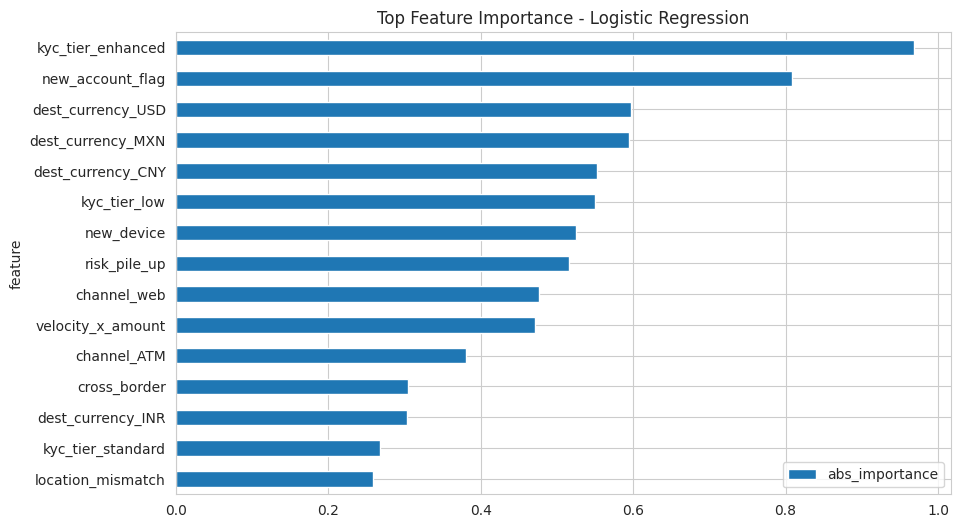

In [32]:
importance = pd.DataFrame({
    "feature": processed_features,
    "importance": log_model.named_steps["classifier"].coef_[0]
})

importance["abs_importance"] = importance["importance"].abs()
importance = importance.sort_values("abs_importance", ascending=False)

# Display top 15
print(importance.head(15))

# Plot top 15
importance.head(15).plot.barh(x="feature", y="abs_importance", figsize=(10,6))
plt.title("Top Feature Importance - Logistic Regression")
plt.gca().invert_yaxis()
plt.show()

#### **Feature Importance Analysis**

**Observation**

From the logistic regression coefficients (after preprocessing):

- High-impact positive features (increase fraud probability):

    - new_account_flag – newer accounts are riskier.

    - risk_pile_up – multiple simultaneous risk signals significantly increase predicted fraud.

    - Certain dest_currency values (e.g., MXN, CNY) – may indicate higher-risk corridors.

    - channel_web – web transactions may carry slightly higher fraud likelihood.

    - velocity_x_amount – high transaction velocity combined with amount is predictive.

- High-impact negative features (decrease fraud probability):

    - kyc_tier_enhanced – enhanced KYC reduces fraud likelihood.

    - new_device – in combination with other factors, some device flags reduce probability.

    - dest_currency_USD and dest_currency_INR – transactions in these currencies are less likely fraudulent.

    - channel_ATM – ATM usage reduces predicted fraud probability in this dataset.

**Key Takeaways**

1.  Velocity, account age, device trust, and multiple simultaneous risk flags remain the strongest signals for fraud.

2.  KYC tier and transaction corridor provide protective signals; stronger verification and lower-risk destinations reduce fraud likelihood.

3.  Despite feature engineering, overall model performance is limited by small fraud sample size (39 cases) and weak signal separation, which constrains PR-AUC (~ 0.071) and recall (~49%).

4.  PR-AUC is the preferred metric because detecting fraud in a highly imbalanced dataset matters more than overall accuracy — we care about identifying the rare positive cases effectively.


